# Rate Vs Threshold Scan Heatmaps

This notebook reads the 2026-05-20 threshold scan text file and draws one canvas per SLAB. Inside each canvas, every SKIROC is shown as a 2D threshold-channel heatmap.

- x: threshold
- y: channel number from `CH`
- z/color: Y-axis values from the data file


In [1]:
from __future__ import annotations

import math
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_FILE = Path(
    "/home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/Comission/ThresholdScan/"
    "RateVsThresholdScan_05202026_SLBoard_06+05+04+03+07+02+08.txt"
)
OUT_DIR = Path("/home/llr/ilc/shi/code/TB_2026_6/ThresholdScan/figures_rate_vs_threshold")
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.grid": False,
})

DATA_FILE


PosixPath('/home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/Comission/ThresholdScan/RateVsThresholdScan_05202026_SLBoard_06+05+04+03+07+02+08.txt')

## Parse The Scan File

The file stores thresholds once, then stores one Y-value row for every `CORE/SLAB/ASU/SKIROC/CH` combination.

In [2]:
y_header_re = re.compile(
    r"^== Y AXIS for CORE (?P<core>\d+) SLAB (?P<slab>\d+) ASU (?P<asu>\d+) "
    r"SKIROC (?P<skiroc>\d+) CH (?P<ch>\d+) ==$"
)
slboard_re = re.compile(r"SLAB (?P<slab>\d+) == SL BOARD ADD (?P<slboard>\d+)")


def parse_rate_vs_threshold(path: Path):
    lines = path.read_text().splitlines()
    thresholds = None
    slboard_by_slab = {}
    data = defaultdict(dict)

    for index, line in enumerate(lines):
        slboard_match = slboard_re.search(line)
        if slboard_match:
            slboard_by_slab[int(slboard_match.group("slab"))] = int(slboard_match.group("slboard"))

        if line.startswith("== X AXIS"):
            thresholds = np.array([float(x) for x in lines[index + 1].split()], dtype=float)
            continue

        y_match = y_header_re.match(line)
        if y_match:
            if thresholds is None:
                raise ValueError("Y-axis rows appeared before the threshold axis was parsed.")

            values = np.array([float(x) for x in lines[index + 1].split()], dtype=float)
            if len(values) != len(thresholds):
                raise ValueError(
                    f"Expected {len(thresholds)} values after line {index + 1}, got {len(values)}."
                )

            key = (
                int(y_match.group("core")),
                int(y_match.group("slab")),
                int(y_match.group("asu")),
                int(y_match.group("skiroc")),
            )
            ch = int(y_match.group("ch"))
            data[key][ch] = values

    if thresholds is None:
        raise ValueError("Could not find the threshold axis in the file.")

    return thresholds, dict(data), slboard_by_slab


thresholds, scan_data, slboard_by_slab = parse_rate_vs_threshold(DATA_FILE)

slabs = sorted({key[1] for key in scan_data})
summary = {
    "thresholds": thresholds.astype(int).tolist(),
    "n_thresholds": len(thresholds),
    "n_slab": len(slabs),
    "slabs": slabs,
    "n_skiroc_per_slab": {
        slab: len({key[3] for key in scan_data if key[1] == slab}) for slab in slabs
    },
    "n_channel_per_skiroc": sorted({len(ch_map) for ch_map in scan_data.values()}),
}
summary


{'thresholds': [160,
  164,
  168,
  172,
  176,
  180,
  184,
  188,
  192,
  196,
  200,
  204,
  208,
  212,
  216,
  220,
  224,
  228,
  232,
  236,
  240,
  244,
  248,
  252,
  256],
 'n_thresholds': 25,
 'n_slab': 10,
 'slabs': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 'n_skiroc_per_slab': {0: 16,
  1: 16,
  2: 16,
  3: 16,
  4: 16,
  5: 16,
  6: 16,
  7: 16,
  8: 16,
  9: 16},
 'n_channel_per_skiroc': [64]}

## Plot Helpers

`matplotlib.pyplot.hist2d` is used with `weights`, so each threshold-channel bin is filled by the corresponding Y value from the scan.

In [3]:
def bin_edges_from_centers(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    if len(values) == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5], dtype=float)

    mids = (values[:-1] + values[1:]) / 2
    first = values[0] - (mids[0] - values[0])
    last = values[-1] + (values[-1] - mids[-1])
    return np.concatenate([[first], mids, [last]])


def matrix_for_skiroc(core: int, slab: int, asu: int, skiroc: int):
    ch_map = scan_data[(core, slab, asu, skiroc)]
    channels = np.array(sorted(ch_map), dtype=int)
    matrix = np.vstack([ch_map[ch] for ch in channels])
    return channels, matrix


def plot_slab(core: int, slab: int, asu: int = 0, *, save: bool = True):
    keys = sorted(key for key in scan_data if key[:3] == (core, slab, asu))
    if not keys:
        raise ValueError(f"No data found for CORE {core}, SLAB {slab}, ASU {asu}.")

    skirocs = [key[3] for key in keys]
    ncols = 4
    nrows = math.ceil(len(skirocs) / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.0 * ncols, 3.0 * nrows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    vmax = max(matrix_for_skiroc(core, slab, asu, skiroc)[1].max() for skiroc in skirocs)
    threshold_edges = bin_edges_from_centers(thresholds)
    image = None

    for ax, skiroc in zip(axes, skirocs):
        channels, matrix = matrix_for_skiroc(core, slab, asu, skiroc)
        channel_edges = np.arange(channels.min() - 0.5, channels.max() + 1.5, 1.0)

        x = np.tile(thresholds, len(channels))
        y = np.repeat(channels, len(thresholds))
        weights = matrix.reshape(-1)

        hist, xedges, yedges, image = ax.hist2d(
            x,
            y,
            bins=[threshold_edges, channel_edges],
            weights=weights,
            cmap="viridis",
            vmin=0,
            vmax=vmax,
        )
        ax.set_title(f"SKIROC {skiroc}")
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Channel No. (CH)")
        ax.set_xlim(threshold_edges[0], threshold_edges[-1])
        ax.set_ylim(channel_edges[0], channel_edges[-1])

    for ax in axes[len(skirocs):]:
        ax.set_visible(False)

    slboard = slboard_by_slab.get(slab, "unknown")
    fig.suptitle(f"CORE {core}  SLAB {slab}  SL Board ADD {slboard}  ASU {asu}", fontsize=16)
    if image is not None:
        fig.colorbar(image, ax=axes[:len(skirocs)], label="Y value")

    if save:
        out_path = OUT_DIR / f"rate_vs_threshold_core{core}_slab{slab:02d}_asu{asu}.png"
        fig.savefig(out_path, bbox_inches="tight")
        fig._saved_path = out_path

    return fig


## Draw One Canvas Per SLAB

Set `SLABS_TO_PLOT` to a shorter list, such as `[0]`, when you only want to inspect one slab quickly.

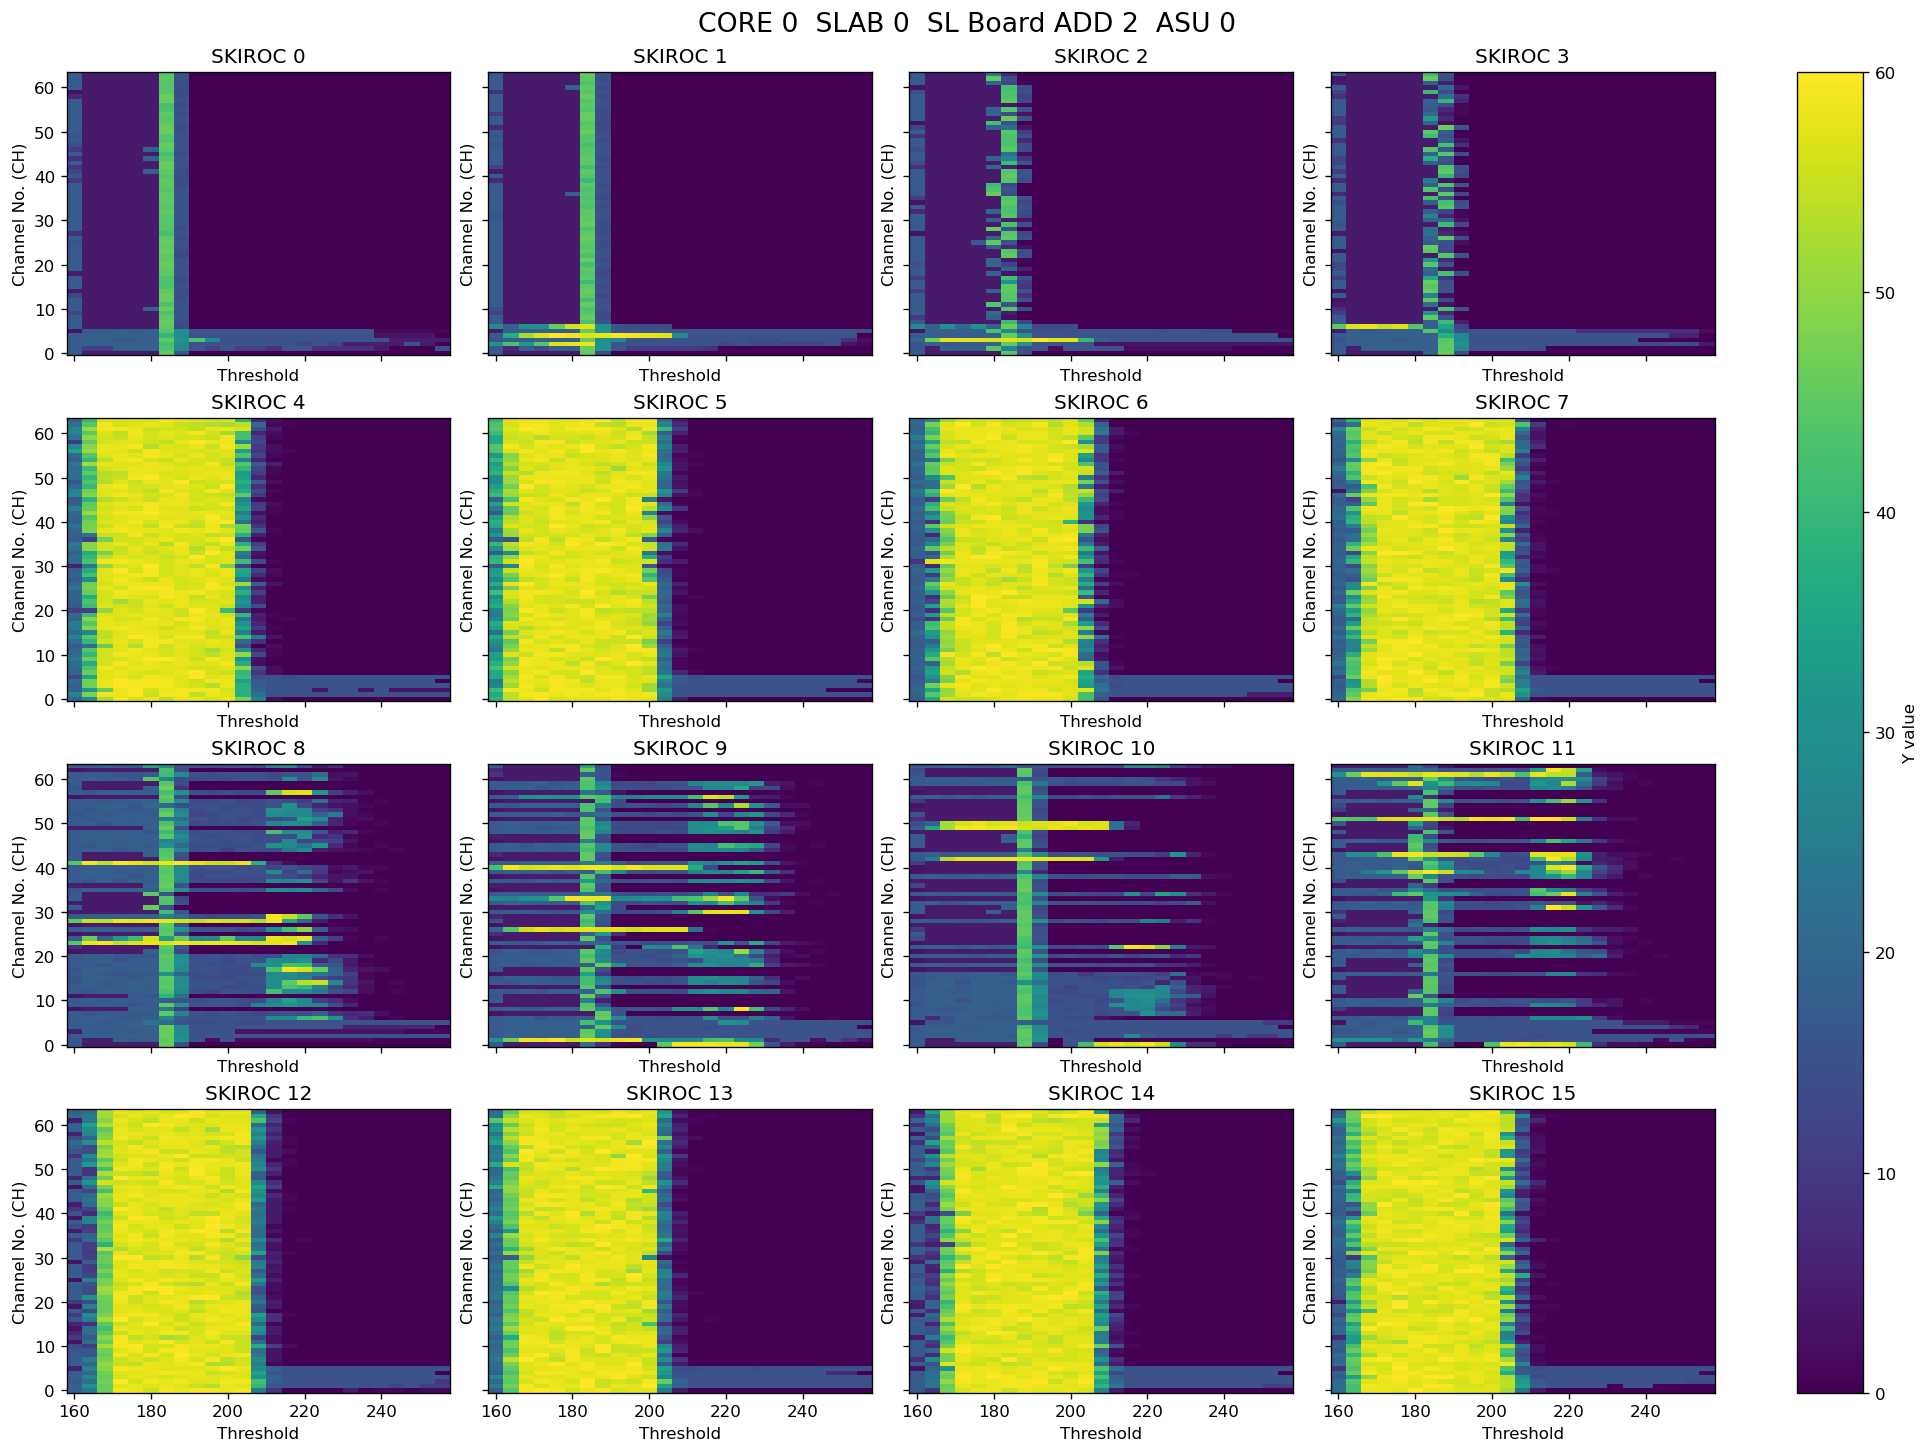

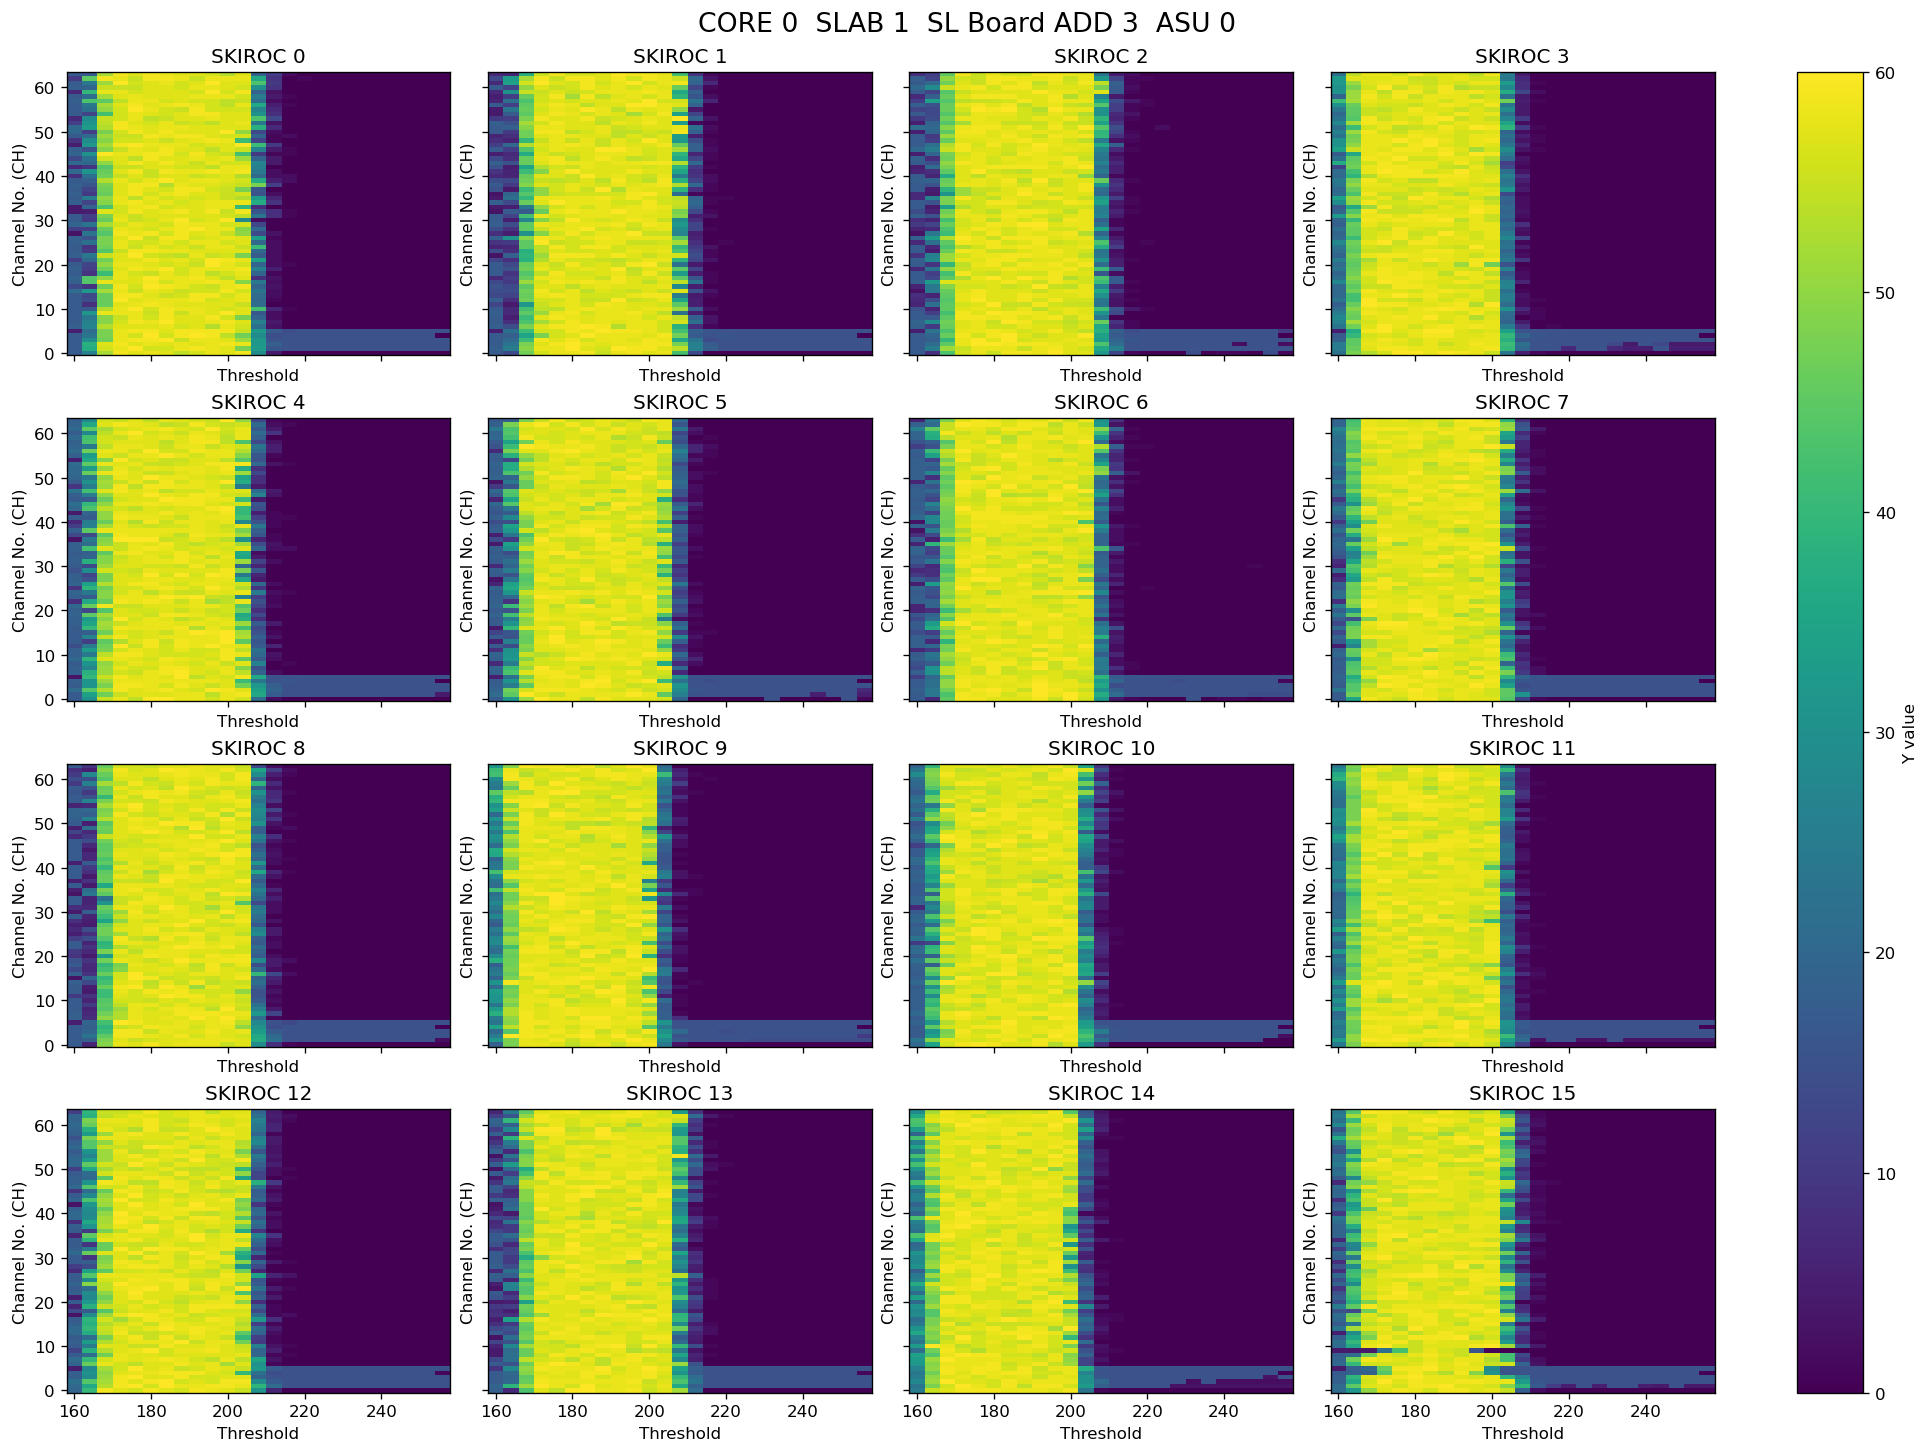

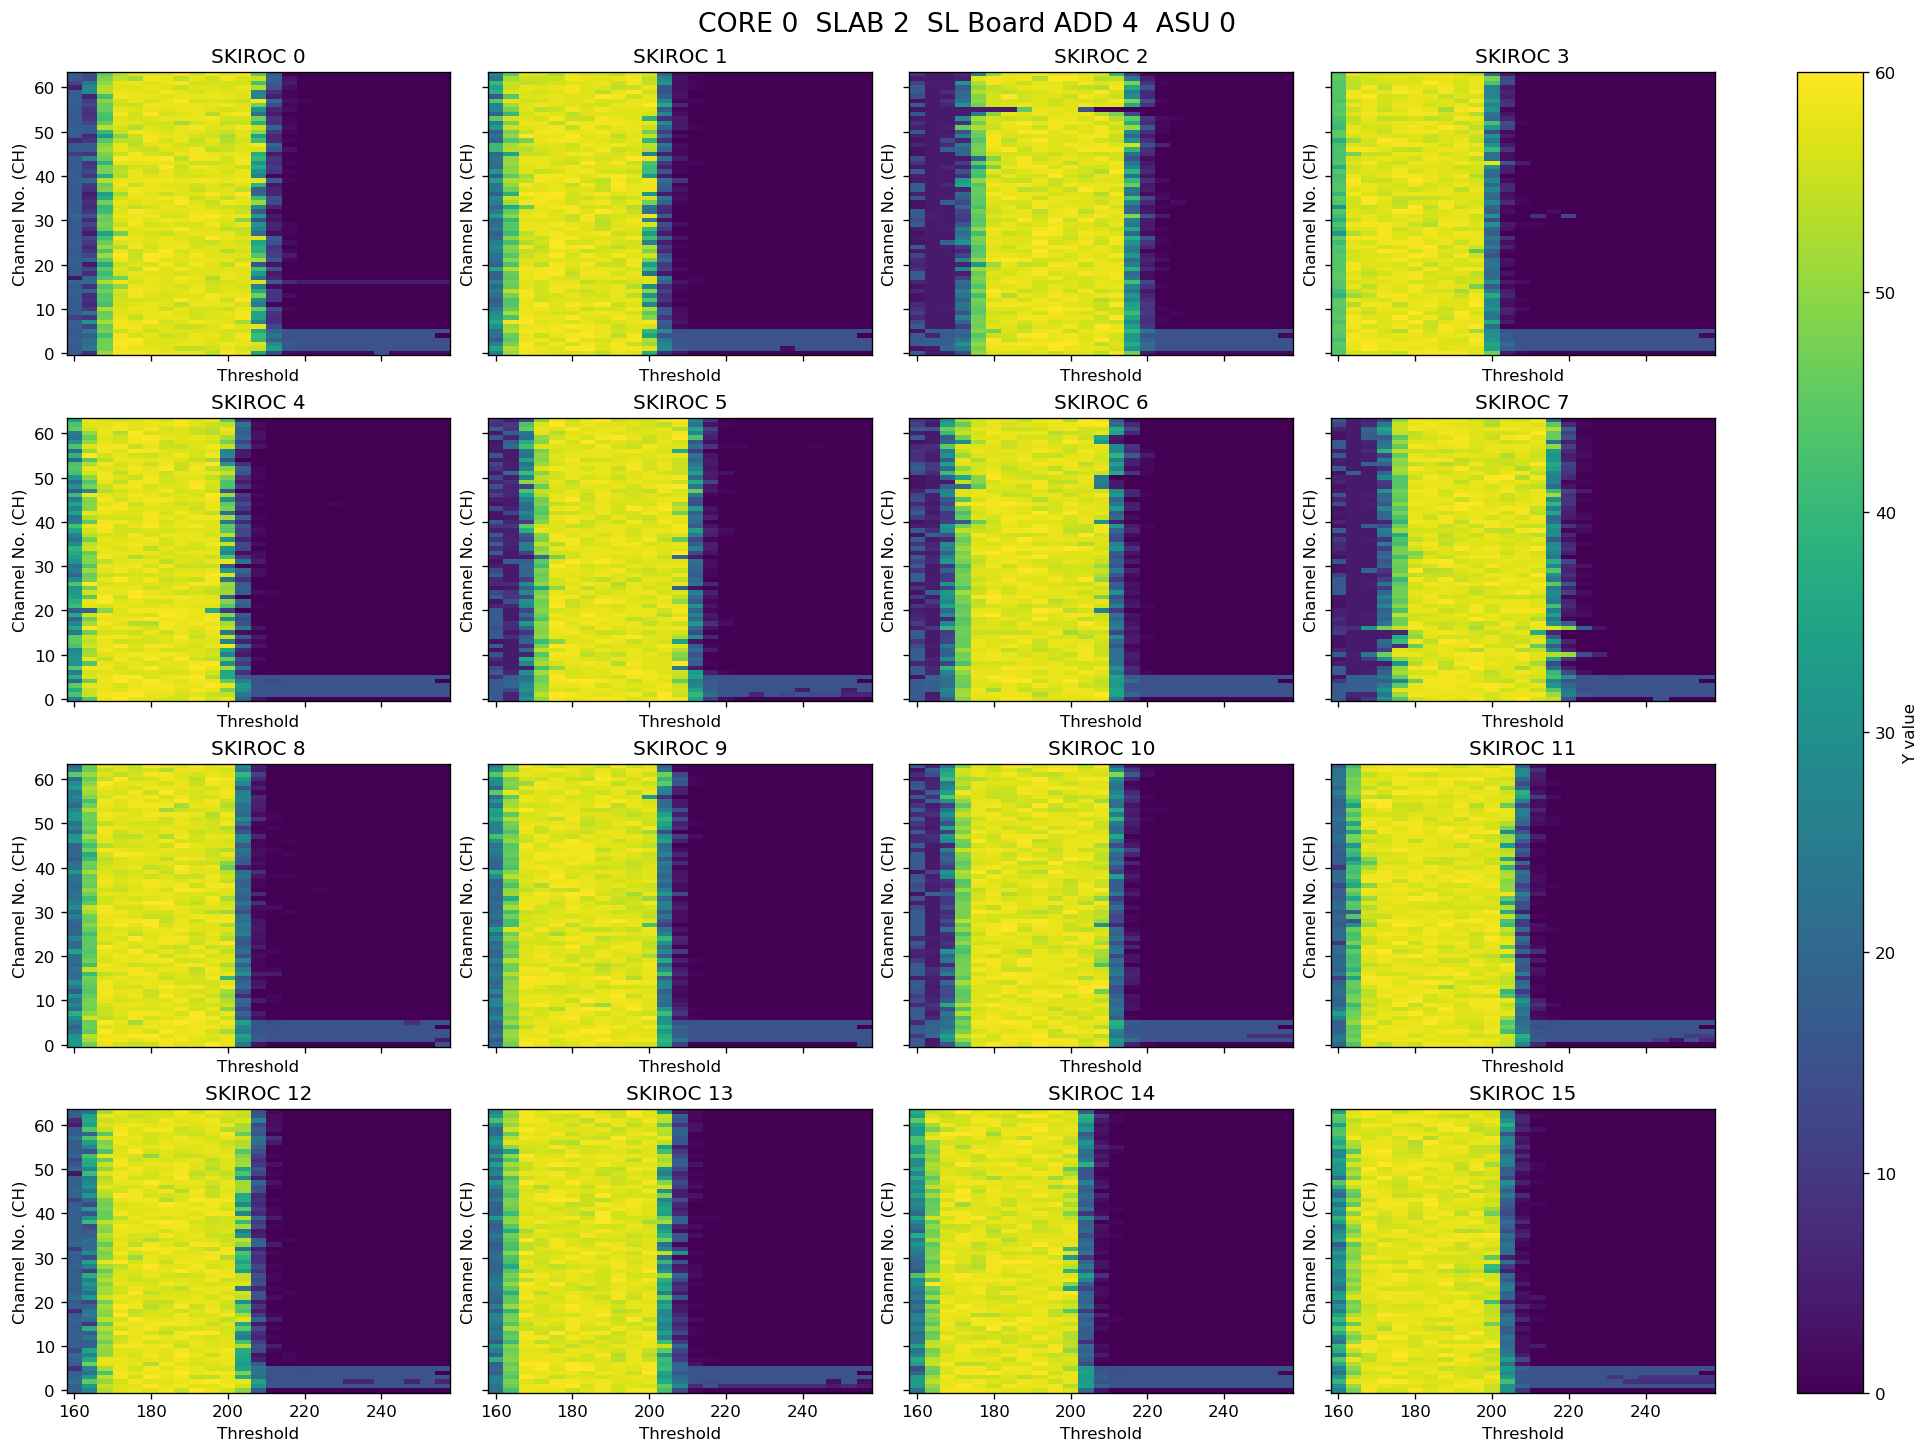

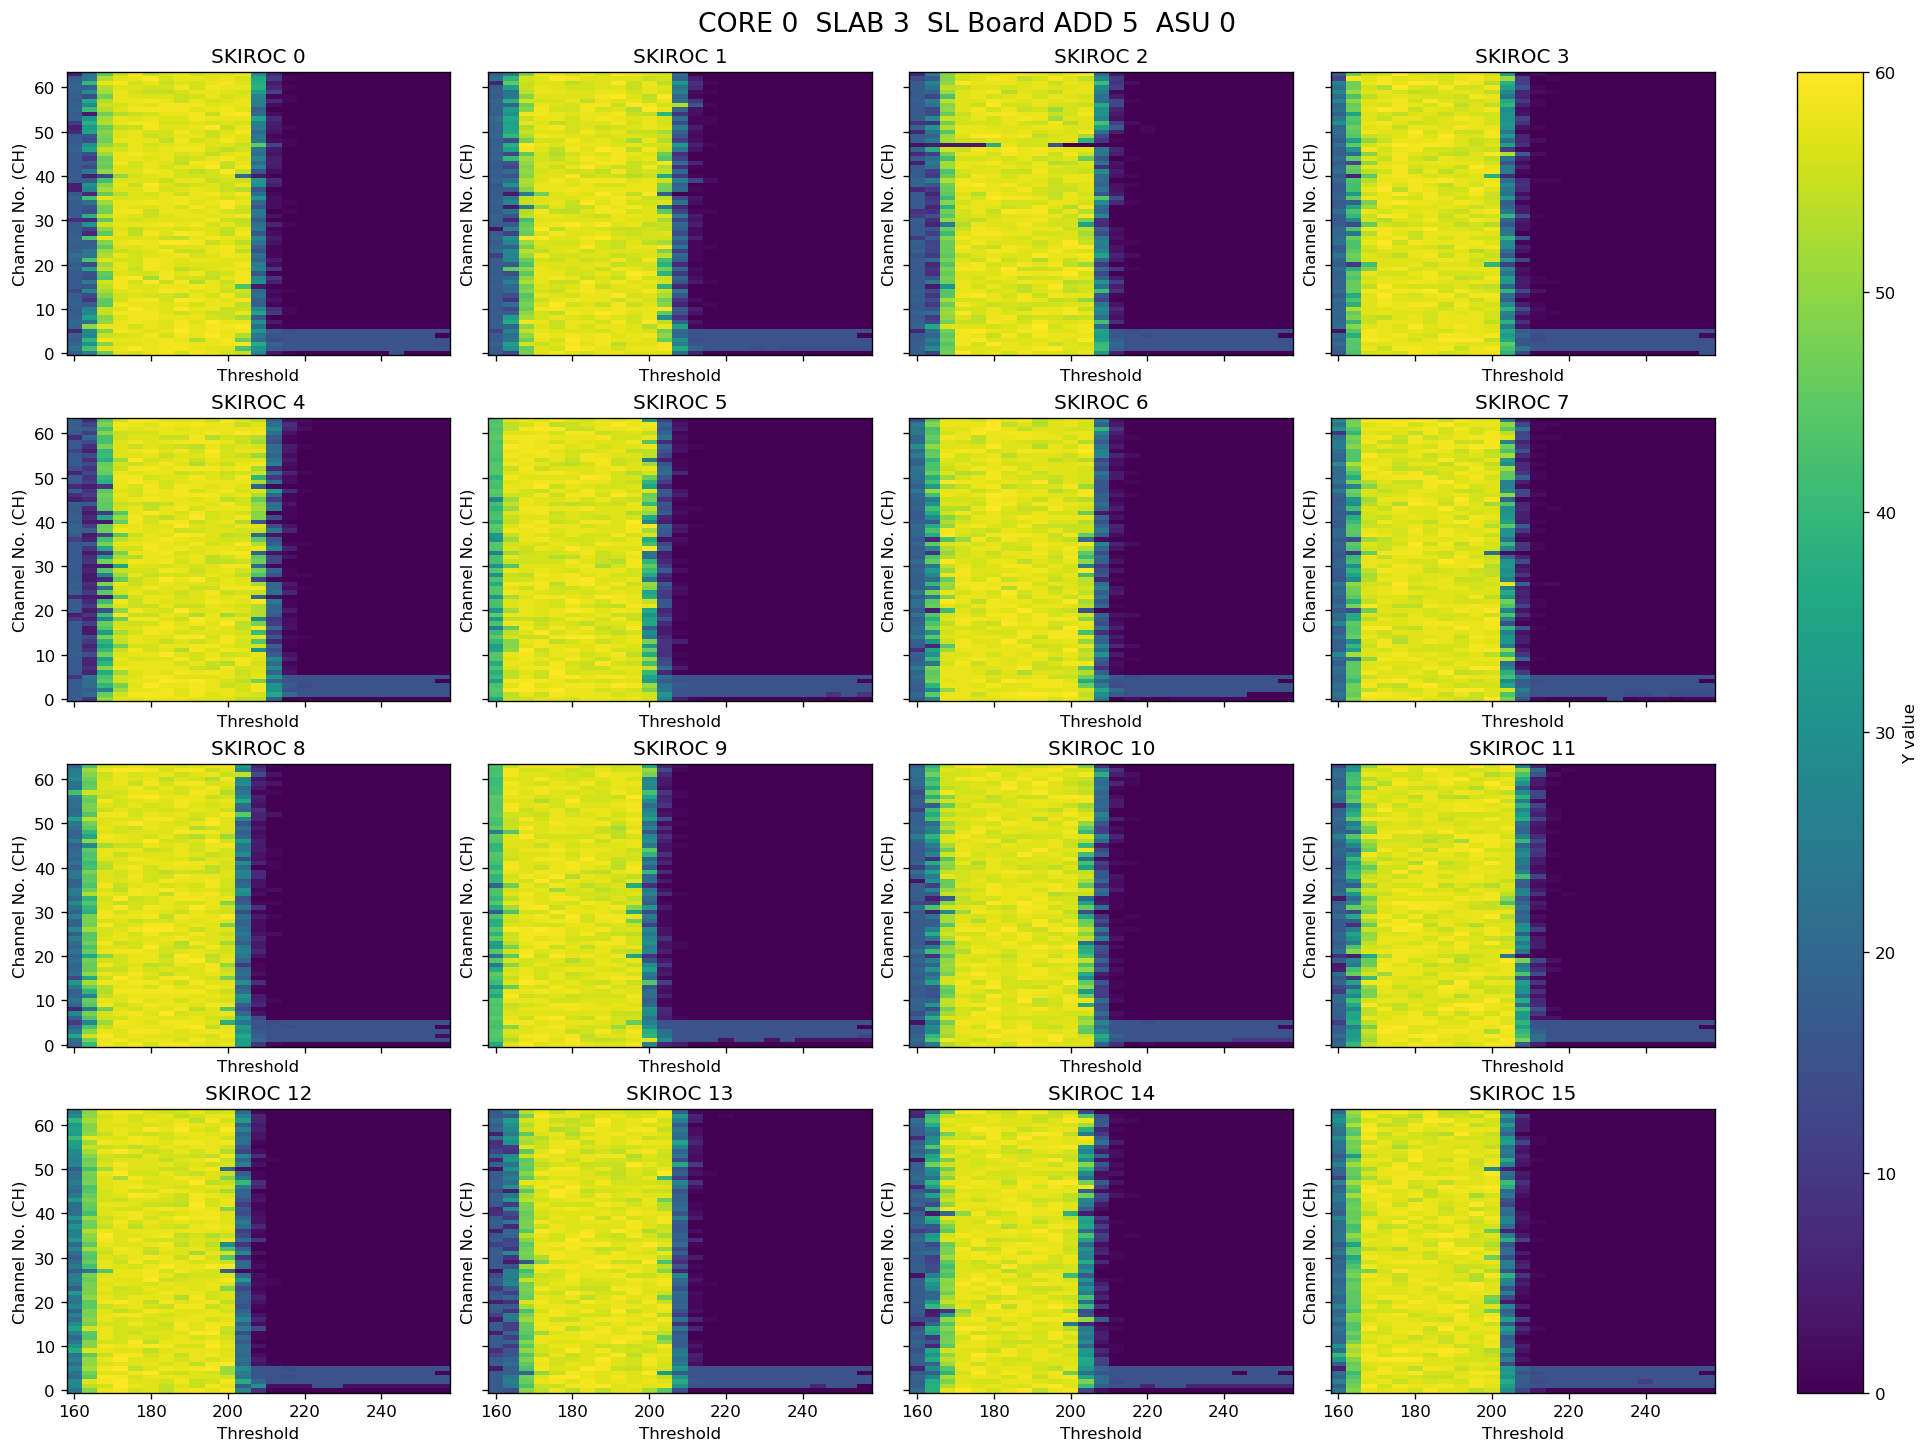

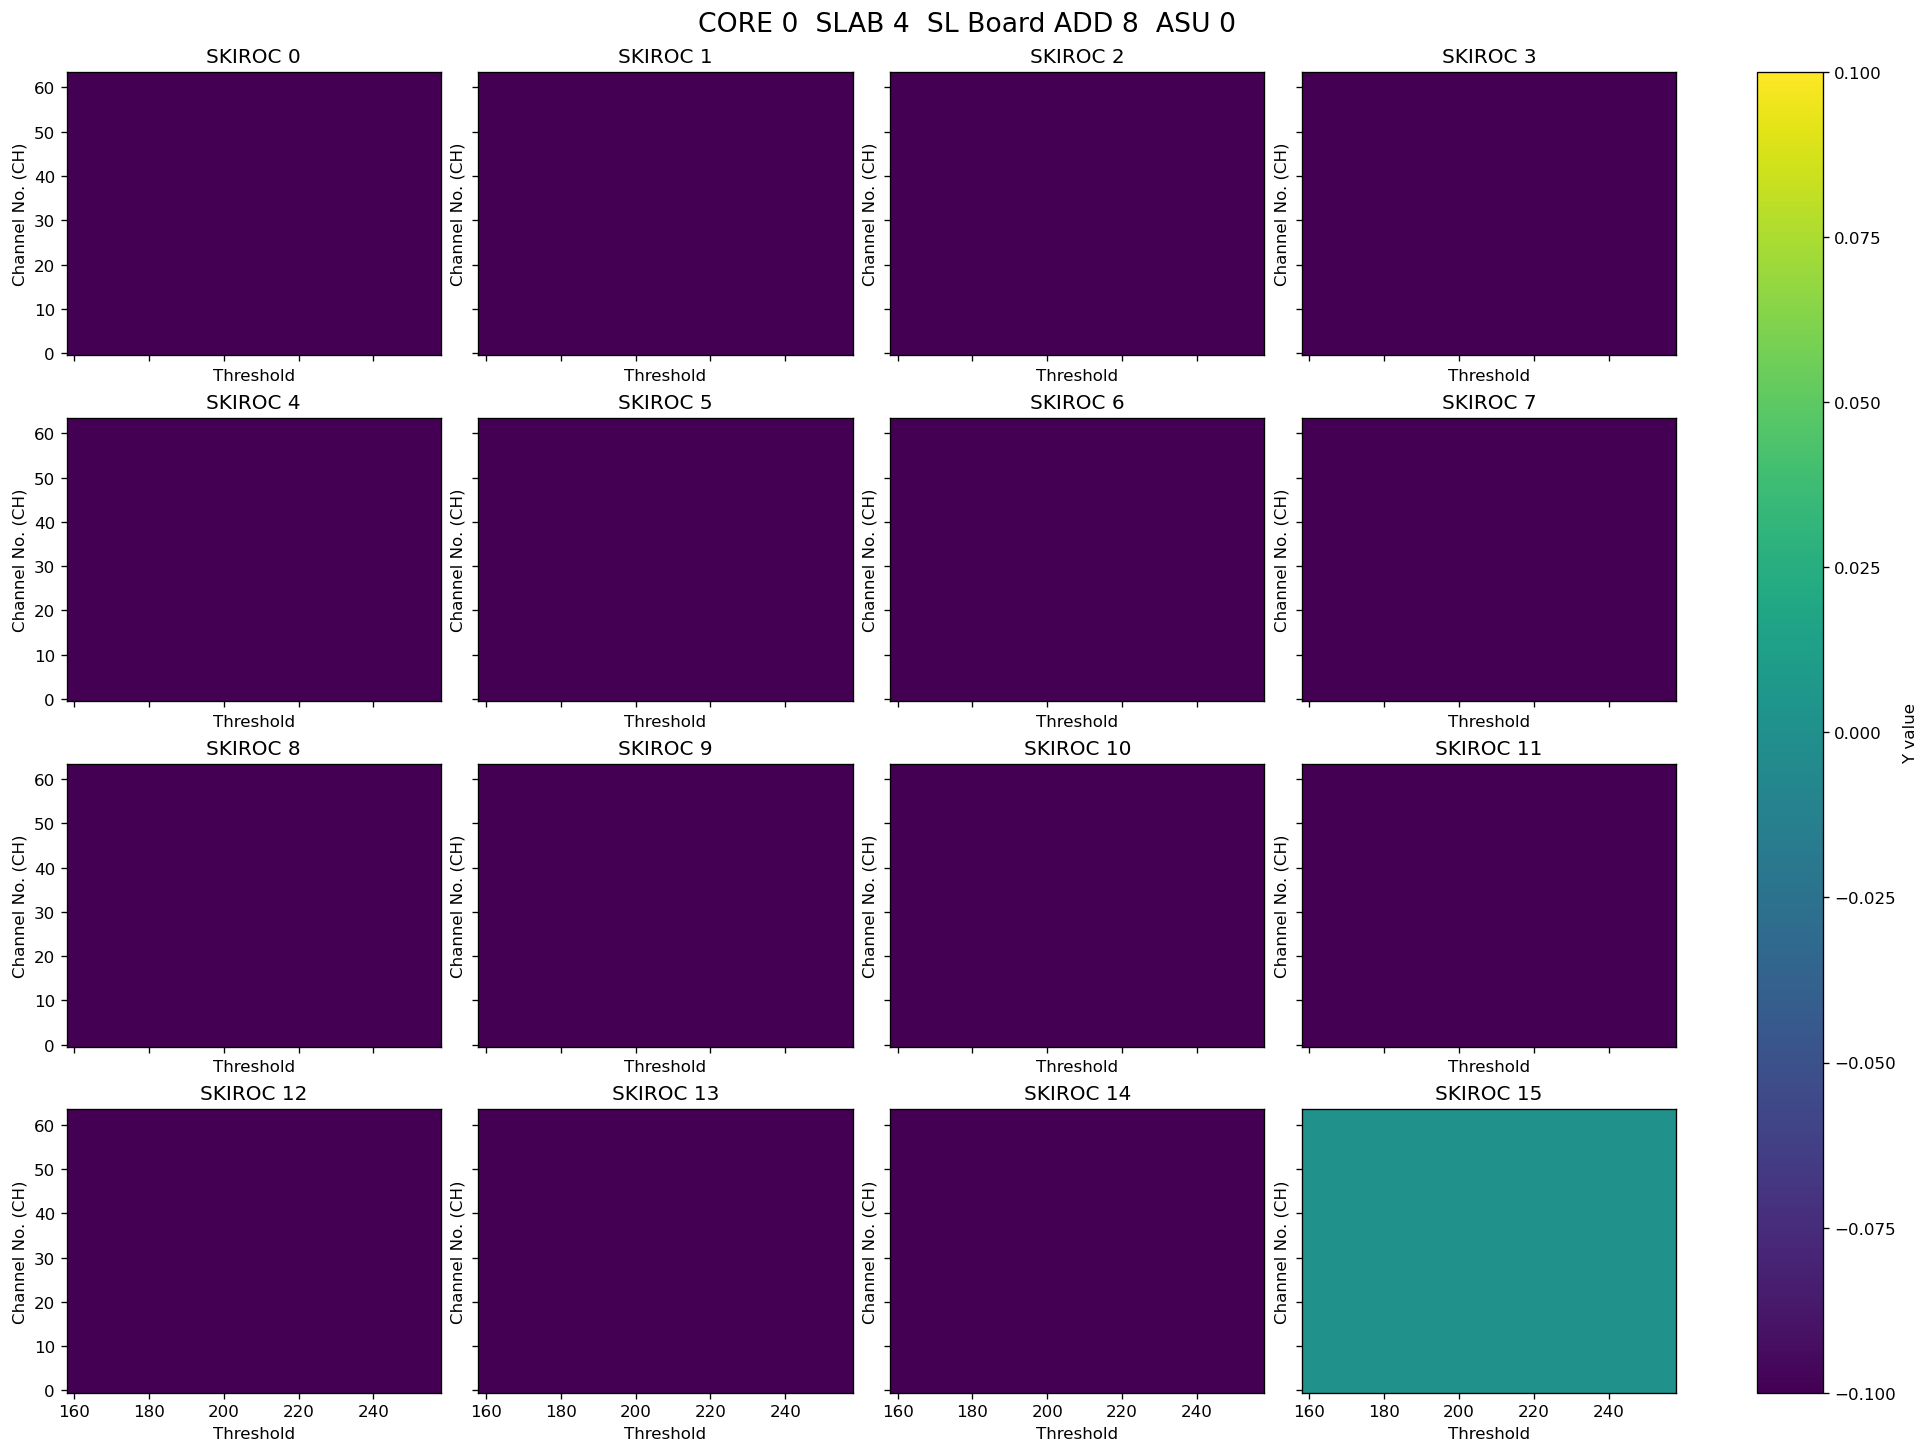

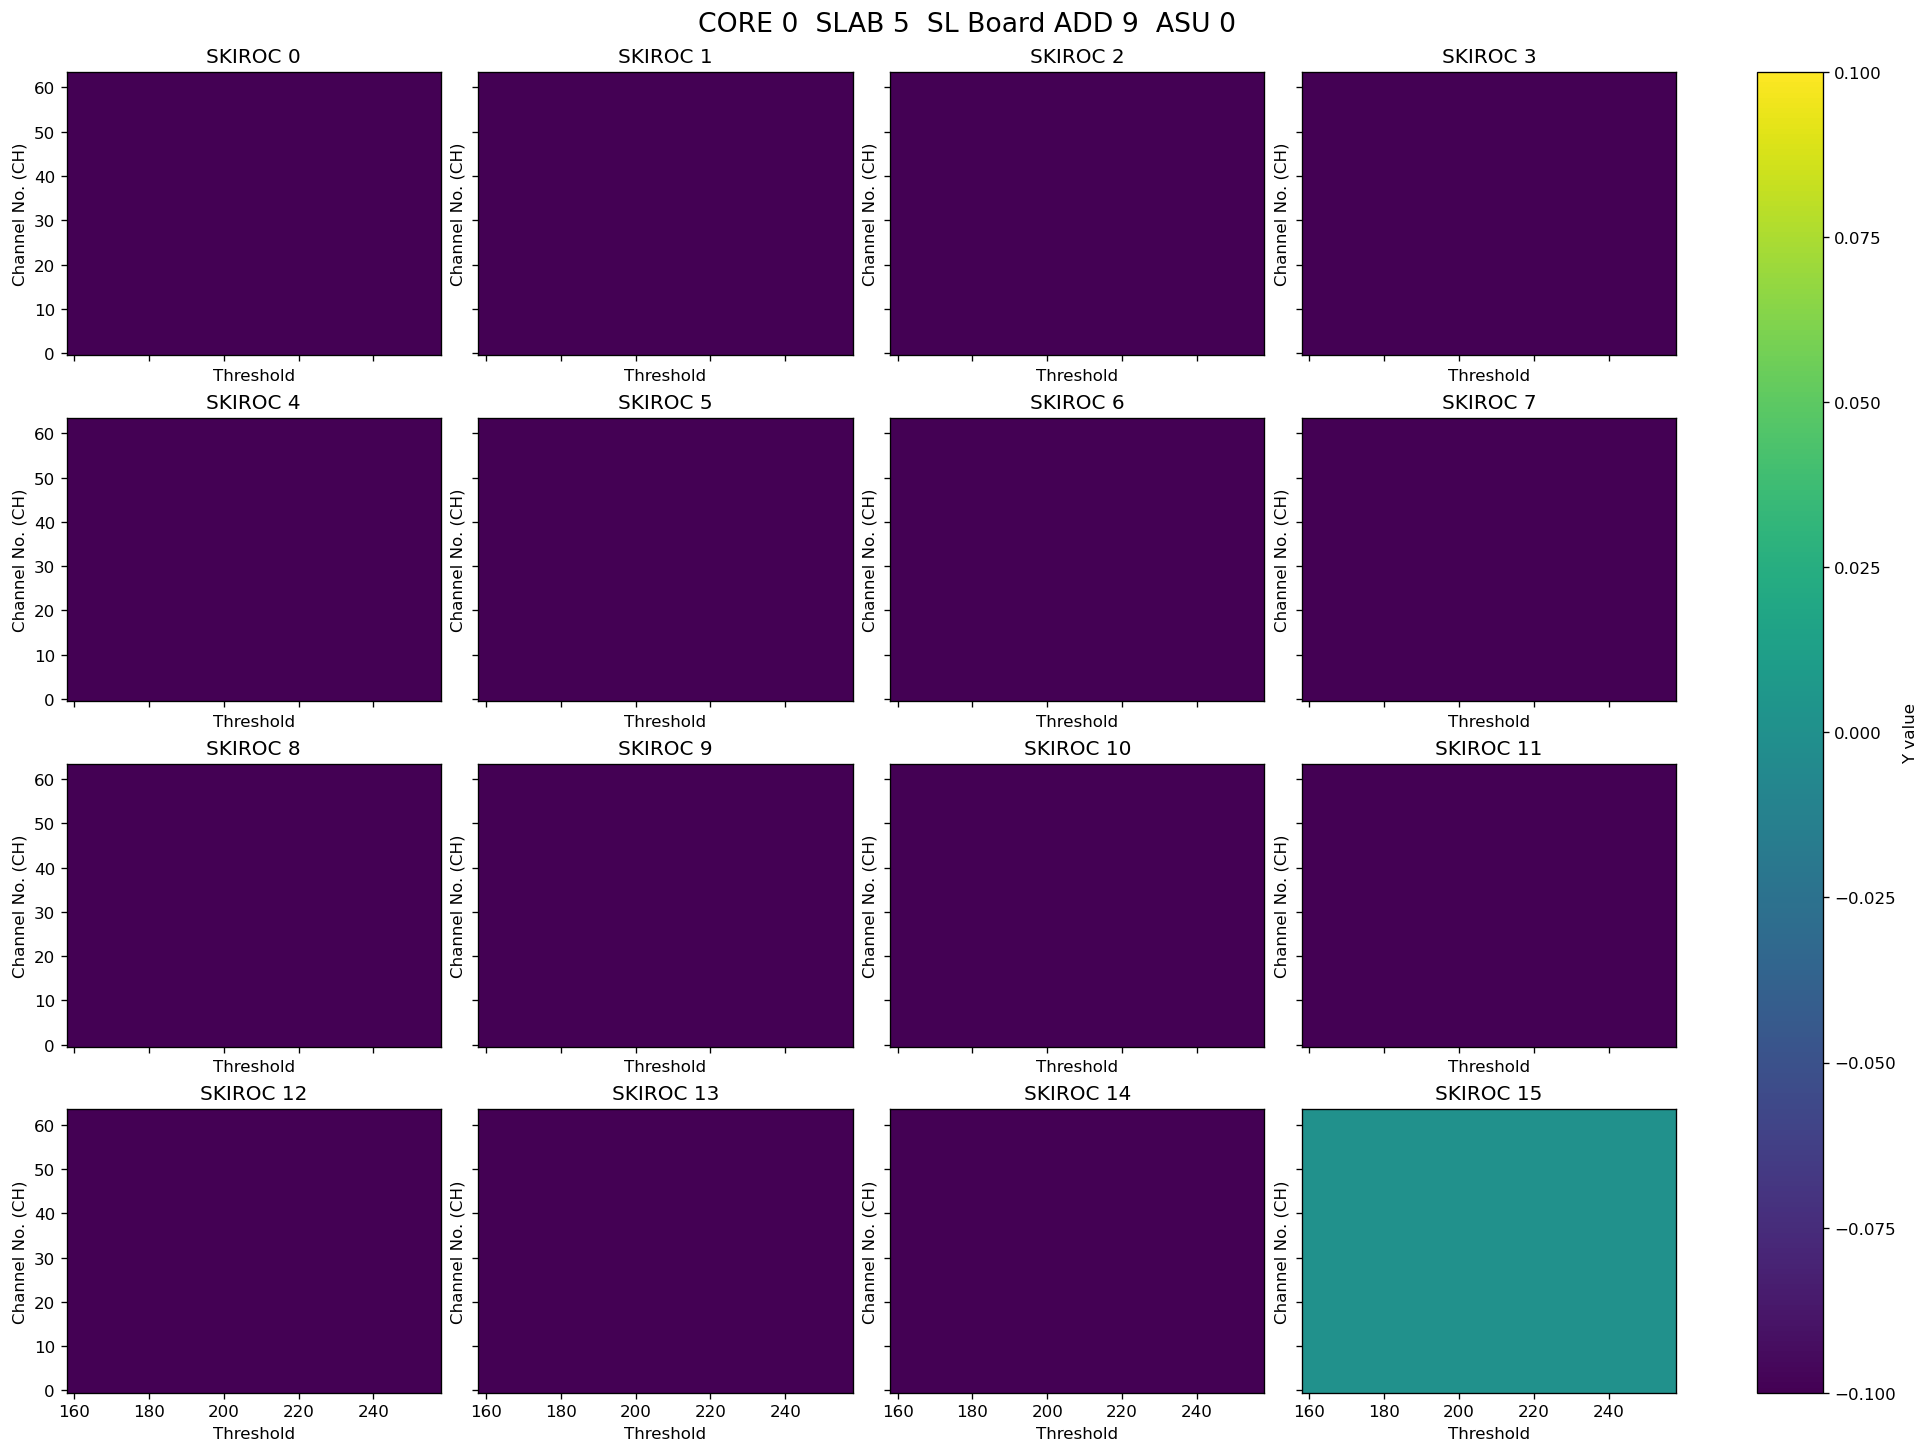

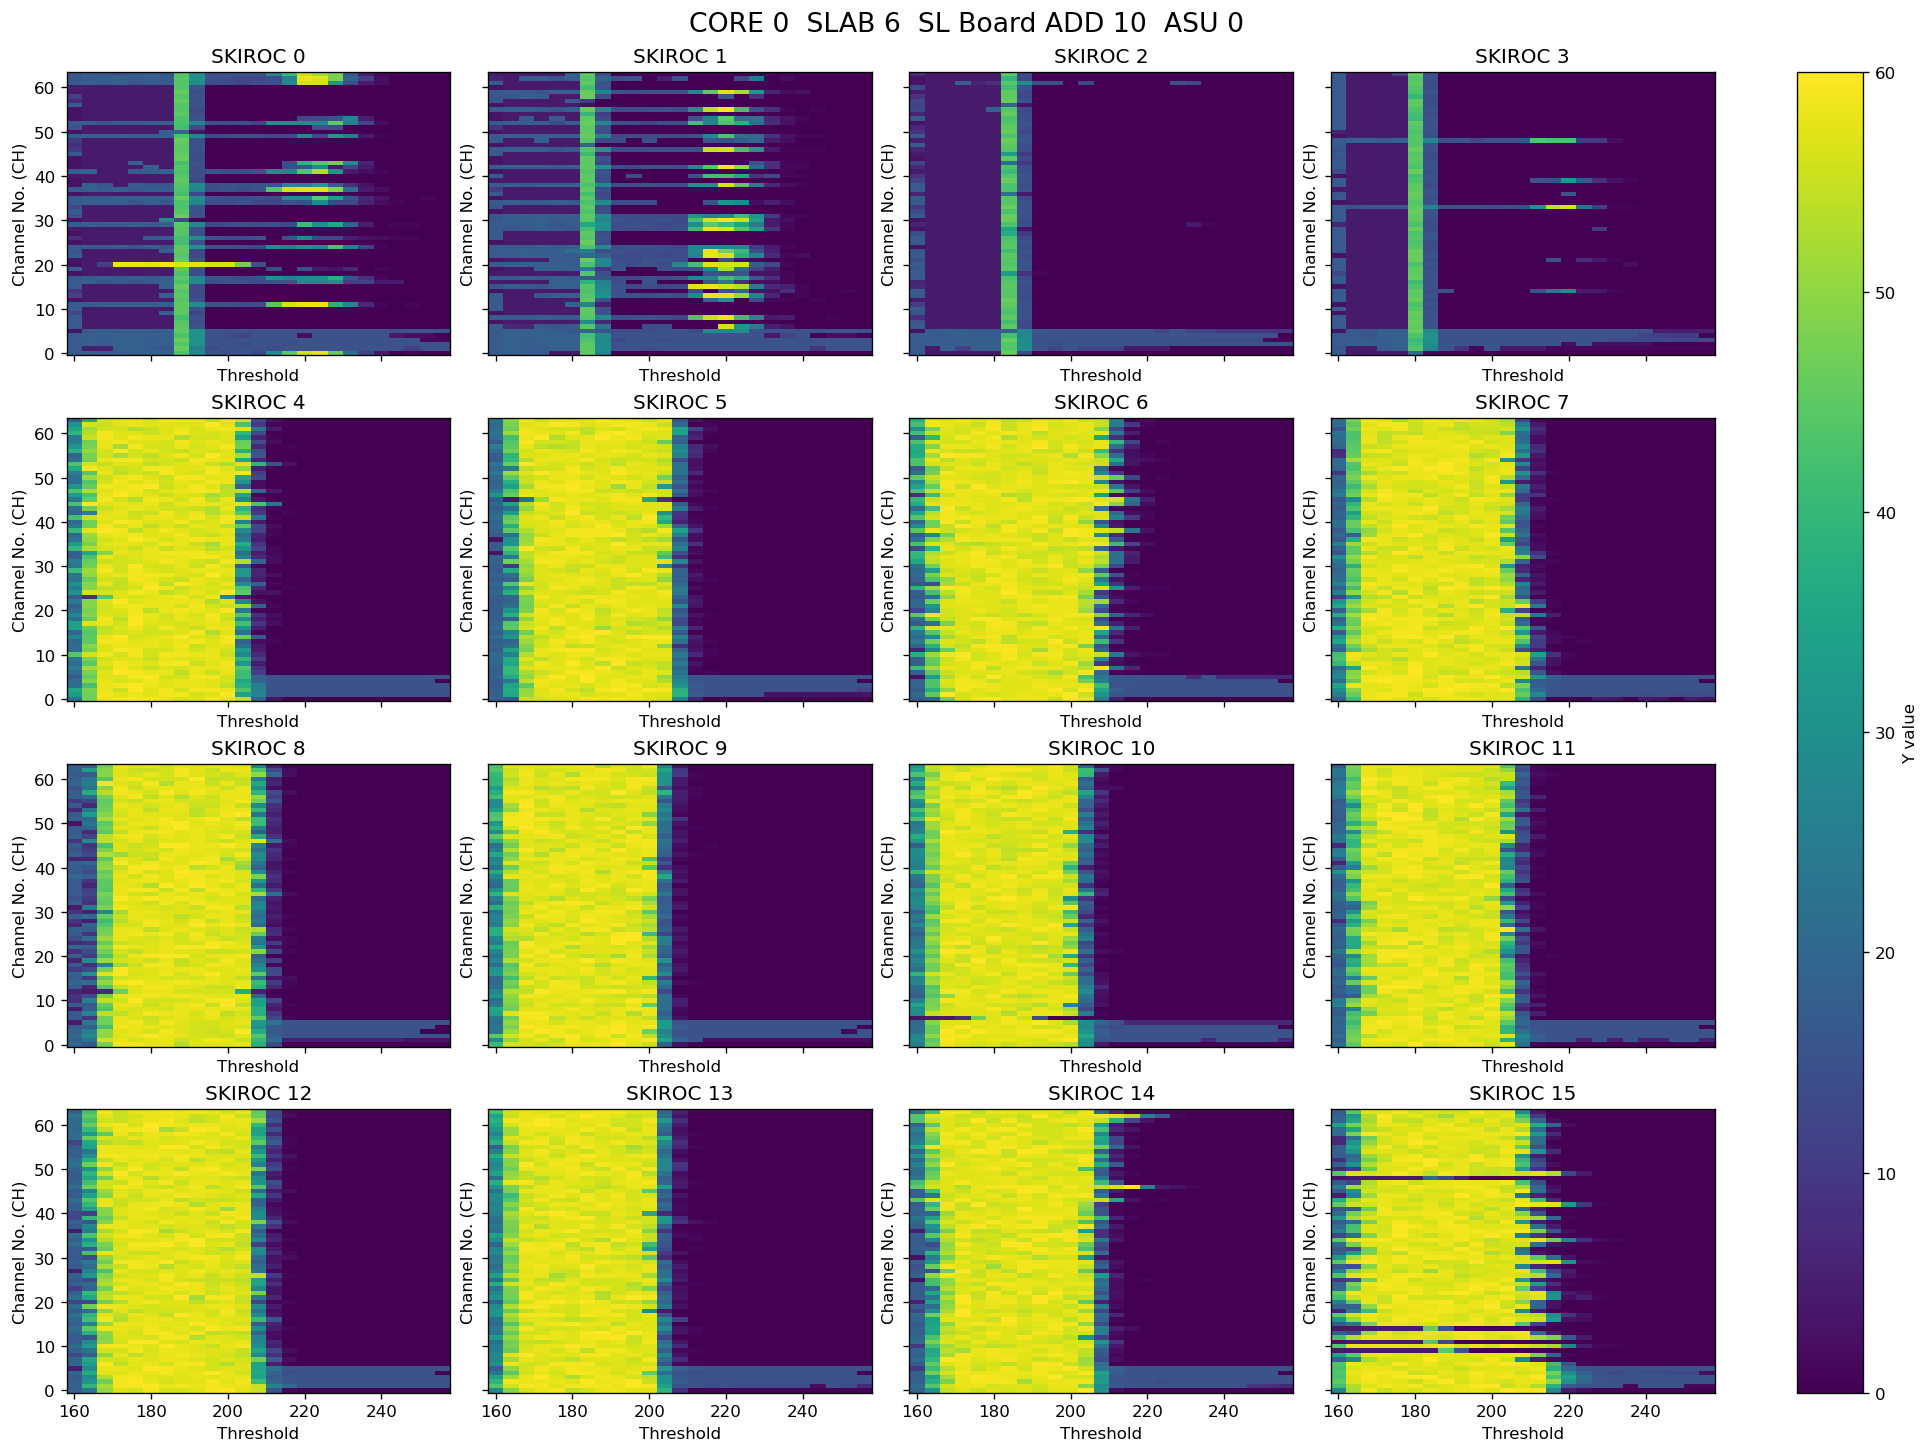

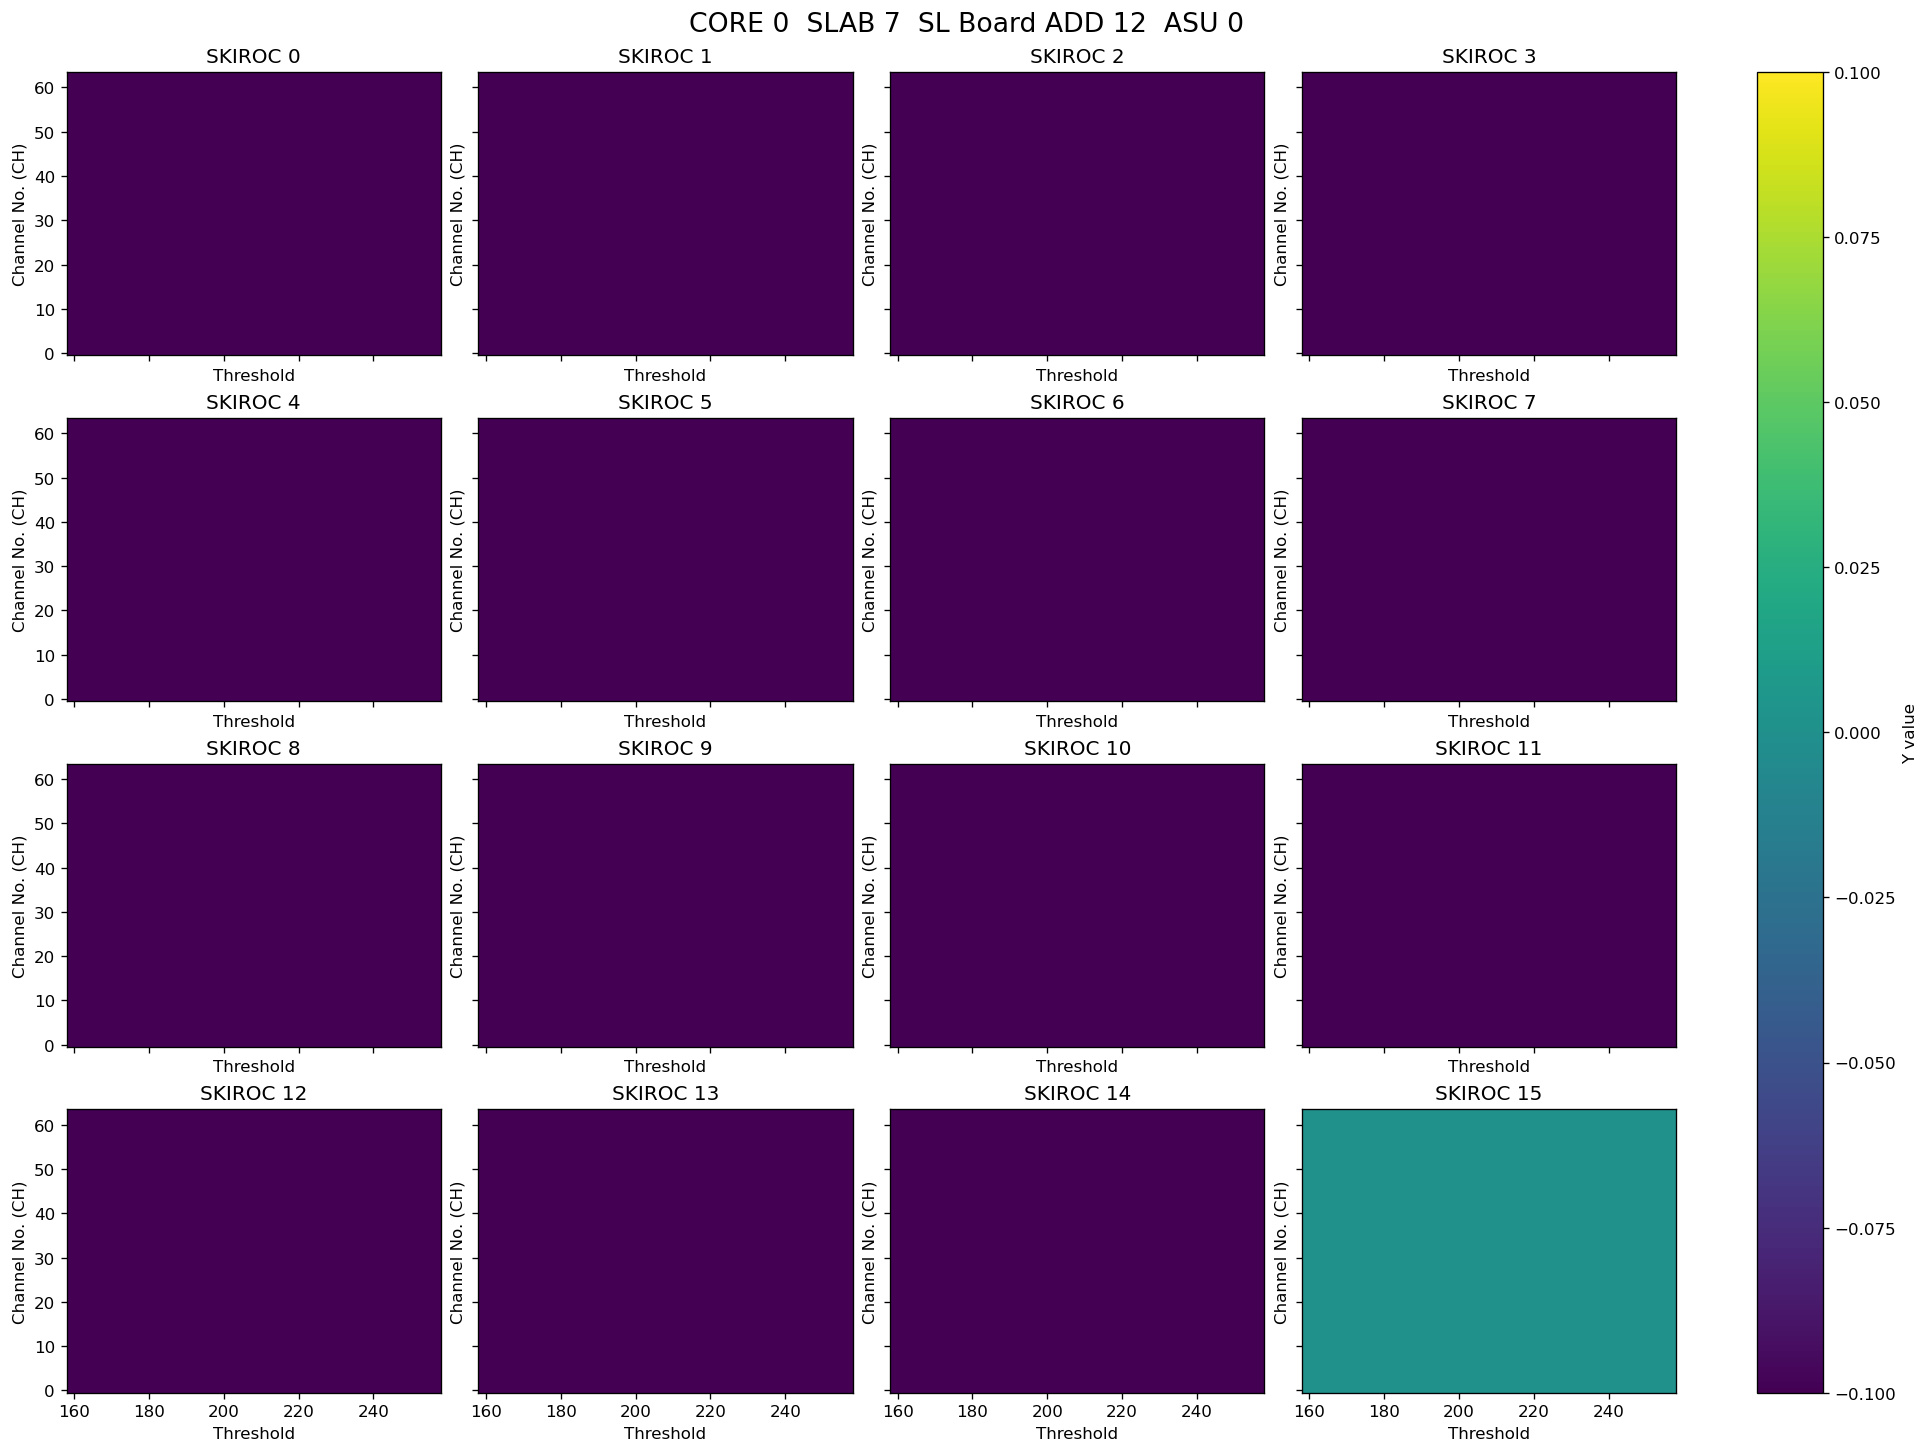

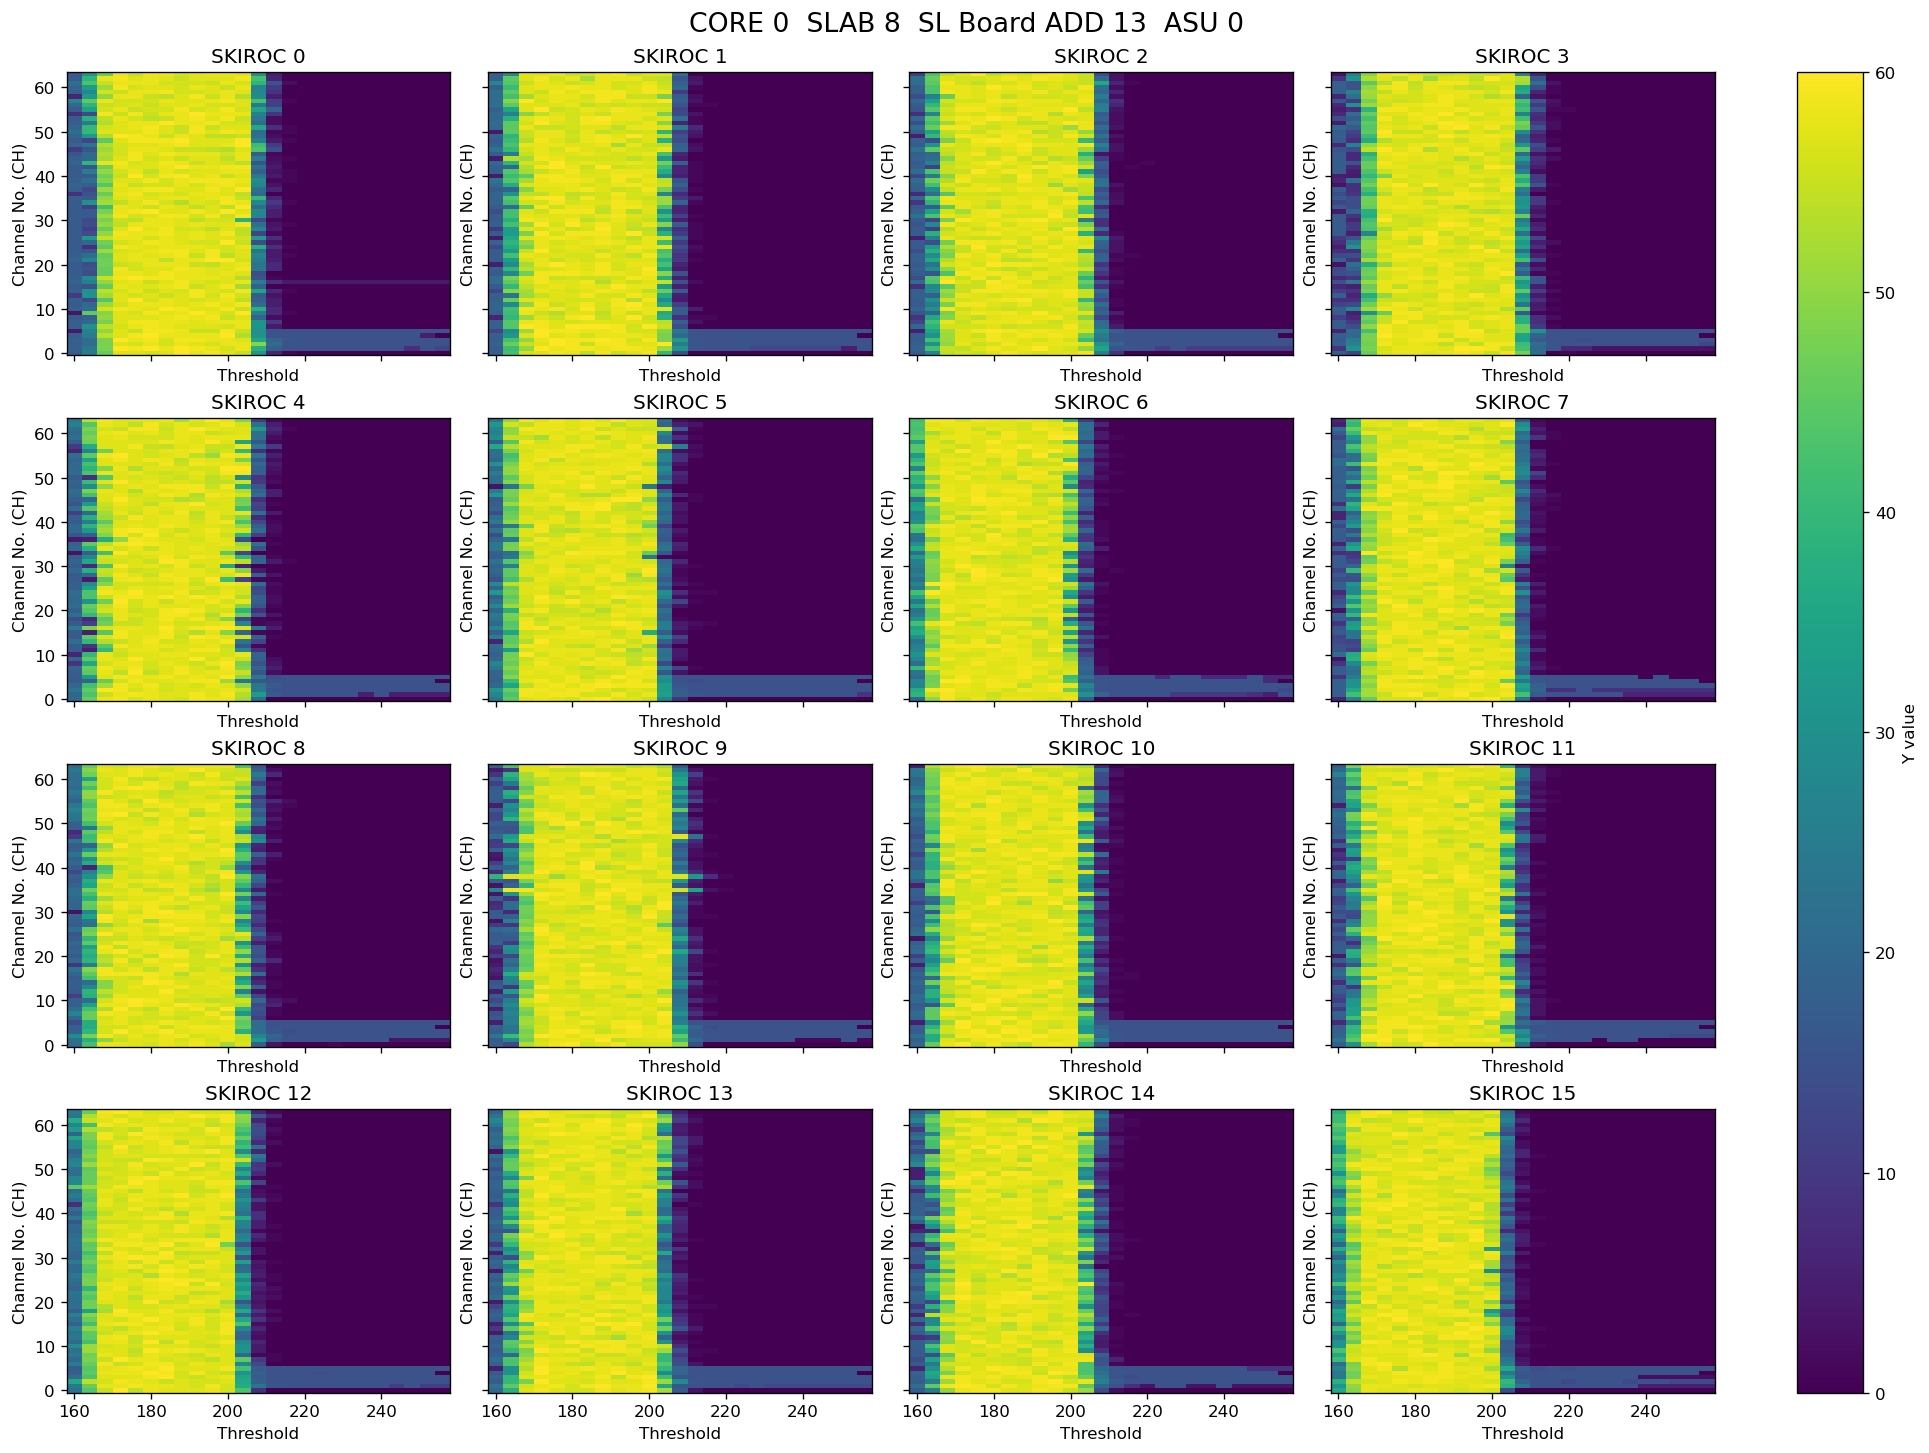

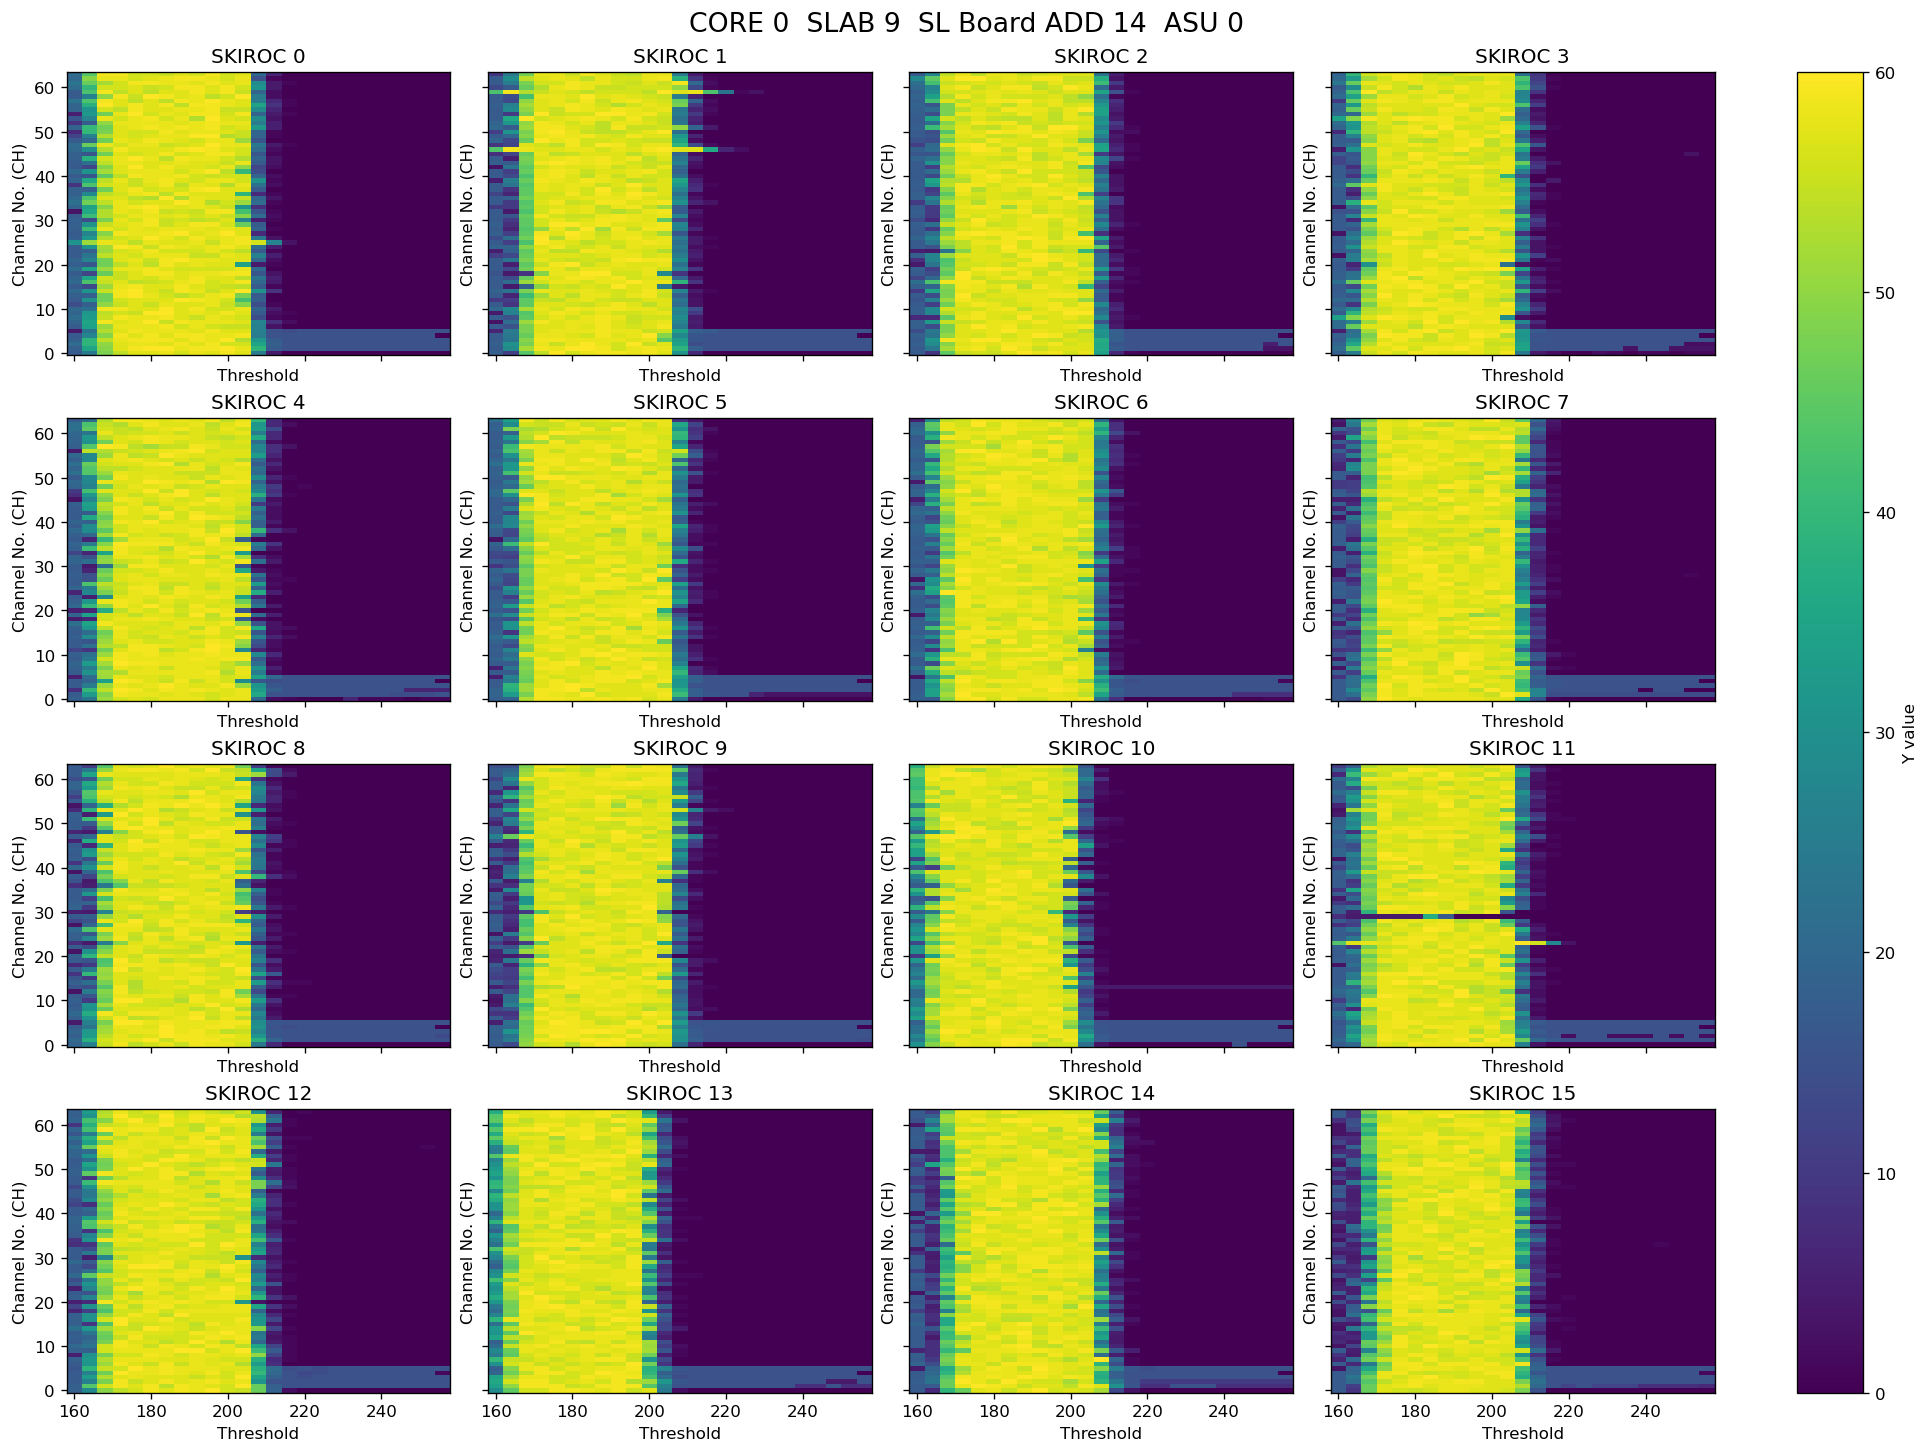

['/home/llr/ilc/shi/code/TB_2026_6/ThresholdScan/figures_rate_vs_threshold/rate_vs_threshold_core0_slab00_asu0.png',
 '/home/llr/ilc/shi/code/TB_2026_6/ThresholdScan/figures_rate_vs_threshold/rate_vs_threshold_core0_slab01_asu0.png',
 '/home/llr/ilc/shi/code/TB_2026_6/ThresholdScan/figures_rate_vs_threshold/rate_vs_threshold_core0_slab02_asu0.png',
 '/home/llr/ilc/shi/code/TB_2026_6/ThresholdScan/figures_rate_vs_threshold/rate_vs_threshold_core0_slab03_asu0.png',
 '/home/llr/ilc/shi/code/TB_2026_6/ThresholdScan/figures_rate_vs_threshold/rate_vs_threshold_core0_slab04_asu0.png',
 '/home/llr/ilc/shi/code/TB_2026_6/ThresholdScan/figures_rate_vs_threshold/rate_vs_threshold_core0_slab05_asu0.png',
 '/home/llr/ilc/shi/code/TB_2026_6/ThresholdScan/figures_rate_vs_threshold/rate_vs_threshold_core0_slab06_asu0.png',
 '/home/llr/ilc/shi/code/TB_2026_6/ThresholdScan/figures_rate_vs_threshold/rate_vs_threshold_core0_slab07_asu0.png',
 '/home/llr/ilc/shi/code/TB_2026_6/ThresholdScan/figures_rate_vs

In [4]:
CORE = 0
ASU = 0
SLABS_TO_PLOT = slabs
SAVE_FIGURES = True

saved_paths = []
for slab in SLABS_TO_PLOT:
    fig = plot_slab(CORE, slab, ASU, save=SAVE_FIGURES)
    saved_paths.append(getattr(fig, "_saved_path", None))
    plt.show()

[str(path) for path in saved_paths if path is not None]
